In [90]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("churn_clean.csv")

# Drop unrelated columns
columns_to_drop = ['Customer_id', 'Zip', 'City', 'State', 'County', 'Lat', 'Lng', 'TimeZone', 'Job', 'Marital', 'Gender']
df = df.drop(columns=columns_to_drop)

# Check for missing values
print(df[['Income', 'Tenure', 'Bandwidth_GB_Year']].isnull().sum())

# Fill missing values
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].mean())
df['Bandwidth_GB_Year'] = df['Bandwidth_GB_Year'].fillna(df['Bandwidth_GB_Year'].median())

# Drop duplicates
df = df.drop_duplicates()

# Confirm data types
print(df[['MonthlyCharge', 'Tenure', 'Income', 'Bandwidth_GB_Year']].dtypes)

Income               0
Tenure               0
Bandwidth_GB_Year    0
dtype: int64
MonthlyCharge        float64
Tenure               float64
Income               float64
Bandwidth_GB_Year    float64
dtype: object


In [92]:
# Show summary statistics for the key variables
summary_stats = df[['MonthlyCharge', 'Tenure', 'Income', 'Bandwidth_GB_Year']].describe()
print(summary_stats)

       MonthlyCharge        Tenure         Income  Bandwidth_GB_Year
count   10000.000000  10000.000000   10000.000000       10000.000000
mean      172.624816     34.526188   39806.926771        3392.341550
std        42.943094     26.443063   28199.916702        2185.294852
min        79.978860      1.000259     348.670000         155.506715
25%       139.979239      7.917694   19224.717500        1236.470827
50%       167.484700     35.430507   33170.605000        3279.536903
75%       200.734725     61.479795   53246.170000        5586.141370
max       290.160419     71.999280  258900.700000        7158.981530


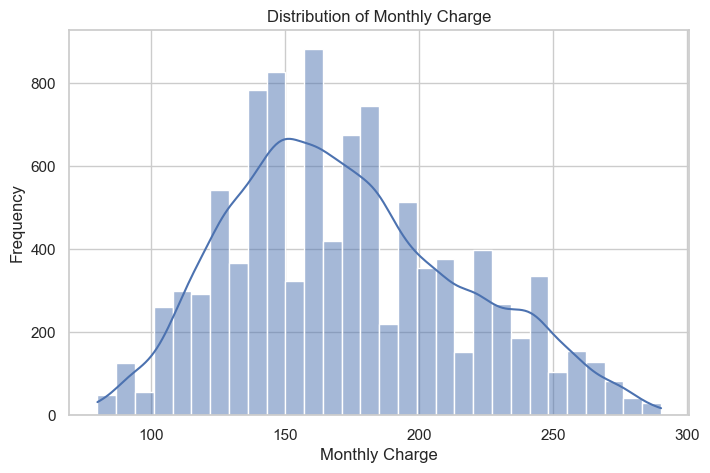

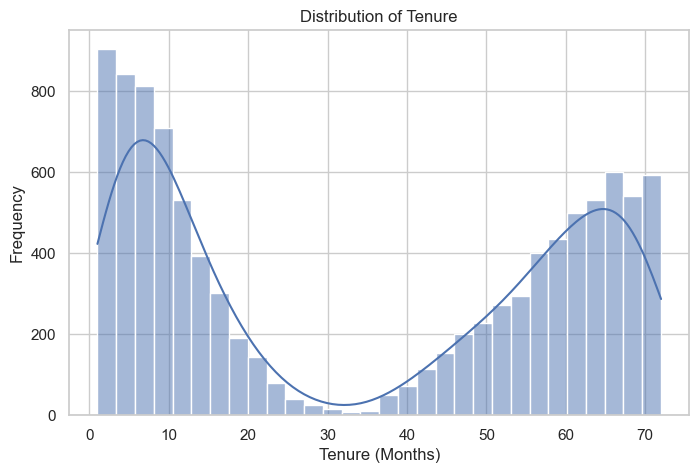

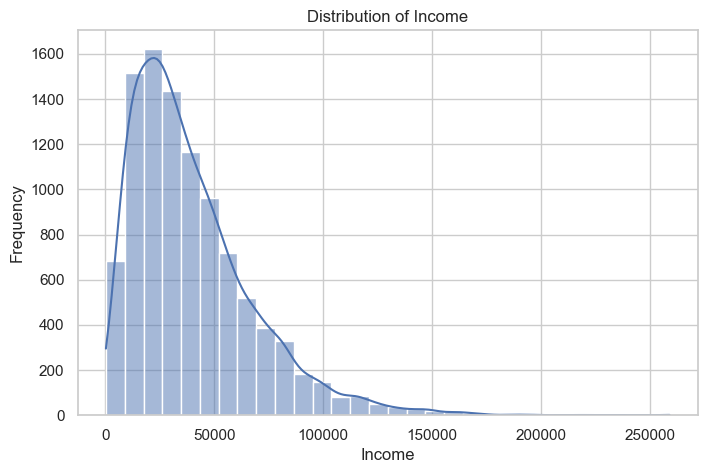

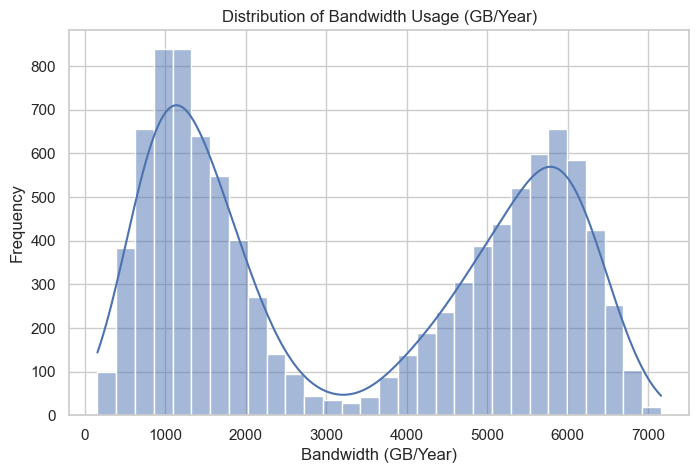

In [94]:
# Set style for all plots
sns.set(style="whitegrid")

# UNIVARIATE VISUALIZATIONS

# MonthlyCharge Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['MonthlyCharge'], bins=30, kde=True)
plt.title("Distribution of Monthly Charge")
plt.xlabel("Monthly Charge")
plt.ylabel("Frequency")
plt.show()

# Tenure Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Tenure'], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()

# Income Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Bandwidth Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Bandwidth_GB_Year'], bins=30, kde=True)
plt.title("Distribution of Bandwidth Usage (GB/Year)")
plt.xlabel("Bandwidth (GB/Year)")
plt.ylabel("Frequency")
plt.show()


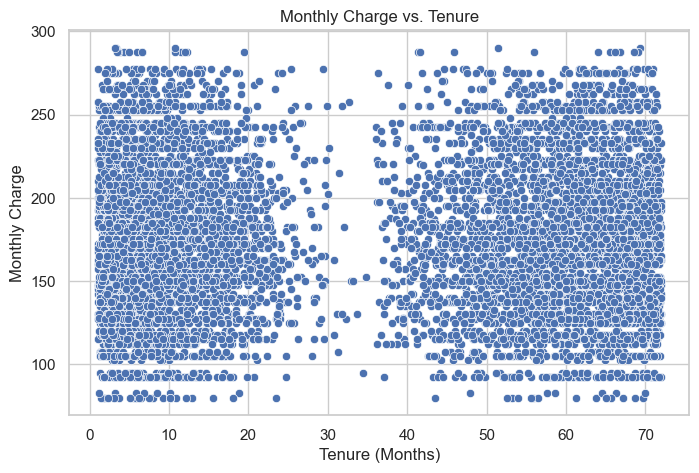

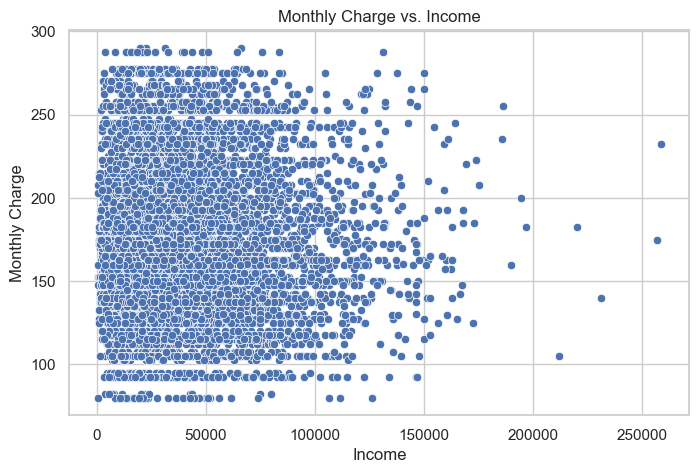

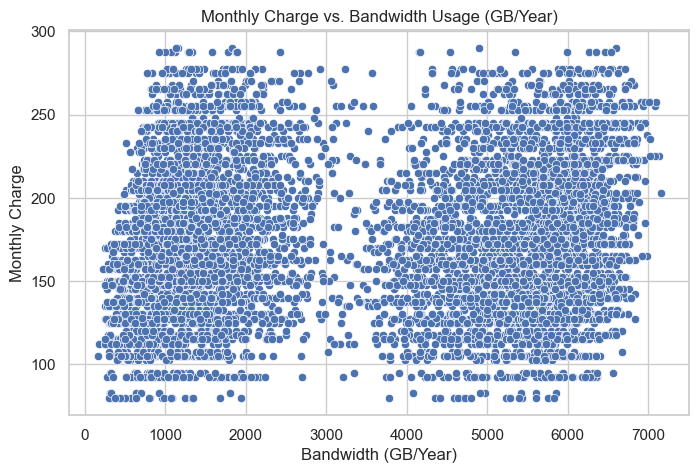

In [96]:
# BIVARIATE VISUALIZATIONS

# MonthlyCharge vs. Tenure
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Tenure', y='MonthlyCharge', data=df)
plt.title("Monthly Charge vs. Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charge")
plt.show()

# MonthlyCharge vs. Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Income', y='MonthlyCharge', data=df)
plt.title("Monthly Charge vs. Income")
plt.xlabel("Income")
plt.ylabel("Monthly Charge")
plt.show()

# MonthlyCharge vs. Bandwidth_GB_Year
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Bandwidth_GB_Year', y='MonthlyCharge', data=df)
plt.title("Monthly Charge vs. Bandwidth Usage (GB/Year)")
plt.xlabel("Bandwidth (GB/Year)")
plt.ylabel("Monthly Charge")
plt.show()

In [98]:
from sklearn.preprocessing import StandardScaler

# Create a copy of the dataset to transform
df_transformed = df.copy()

# Select variables to scale
features_to_scale = ['Tenure', 'Income', 'Bandwidth_GB_Year']

# Initialize the scaler
scaler = StandardScaler()

# Apply the scaler to the selected features
df_transformed[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Confirm transformation
print(df_transformed[features_to_scale].describe().round(2))

         Tenure    Income  Bandwidth_GB_Year
count  10000.00  10000.00           10000.00
mean       0.00      0.00               0.00
std        1.00      1.00               1.00
min       -1.27     -1.40              -1.48
25%       -1.01     -0.73              -0.99
50%        0.03     -0.24              -0.05
75%        1.02      0.48               1.00
max        1.42      7.77               1.72


In [61]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the original dataset
df = pd.read_csv('churn_clean.csv')

# Drop unrelated columns if present (safe drop)
columns_to_drop = ['Customer_id', 'Zip', 'City', 'State', 'County', 'Lat', 'Lng', 'TimeZone', 'Job', 'Marital', 'Gender']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Fill missing values
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].mean())
df['Bandwidth_GB_Year'] = df['Bandwidth_GB_Year'].fillna(df['Bandwidth_GB_Year'].median())

# Drop duplicate rows
df = df.drop_duplicates()

# Make a copy for transformation
df_transformed = df.copy()

# Standardize the independent variables
features_to_scale = ['Tenure', 'Income', 'Bandwidth_GB_Year']
scaler = StandardScaler()
df_transformed[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Save the cleaned and prepared dataset to your D208 folder
df_transformed.to_csv('churn_prepared_for_regression.csv', index=False)

# Confirm it's saved
print("Prepared dataset saved to D208/churn_prepared_for_regression.csv")

Prepared dataset saved to D208/churn_prepared_for_regression.csv


In [69]:
import statsmodels.api as sm

# Define X (independent variables) and y (dependent variable)
X = df_transformed[['Tenure', 'Income', 'Bandwidth_GB_Year']]
y = df_transformed['MonthlyCharge']

# Add a constant to X (for intercept)
X = sm.add_constant(X)

# Fit the initial regression model
initial_model = sm.OLS(y, X).fit()

# Show the model summary
print(initial_model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     1051.
Date:                Wed, 23 Apr 2025   Prob (F-statistic):               0.00
Time:                        19:33:57   Log-Likelihood:                -50417.
No. Observations:               10000   AIC:                         1.008e+05
Df Residuals:                    9996   BIC:                         1.009e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               172.6248      0.37

In [88]:
# Define reduced independent variables (dropping Income)
X_reduced = df_transformed[['Tenure', 'Bandwidth_GB_Year']]
y = df_transformed['MonthlyCharge']

# Add constant
X_reduced = sm.add_constant(X_reduced)

# Fit the reduced model
reduced_model = sm.OLS(y, X_reduced).fit()

# Show model summary
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     1576.
Date:                Wed, 23 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:18:13   Log-Likelihood:                -50417.
No. Observations:               10000   AIC:                         1.008e+05
Df Residuals:                    9997   BIC:                         1.009e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               172.6248      0.37

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     1576.
Date:                Wed, 23 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:18:10   Log-Likelihood:                -50417.
No. Observations:               10000   AIC:                         1.008e+05
Df Residuals:                    9997   BIC:                         1.009e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               172.6248      0.37

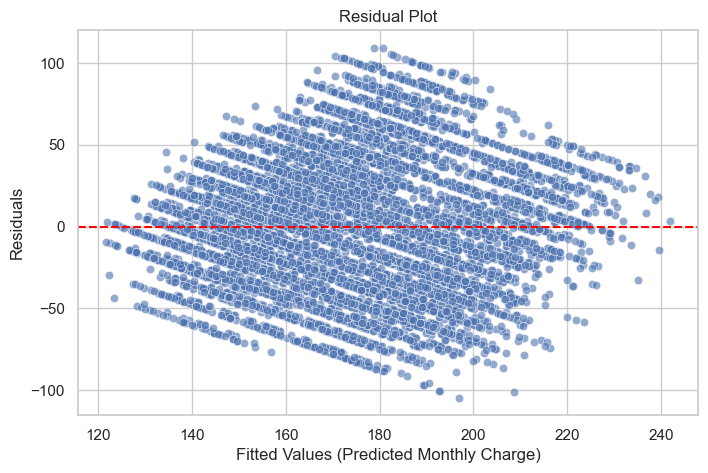

Residual Standard Error (RSE): 37.44


In [86]:
# Define reduced model
X_reduced = df_transformed[['Tenure', 'Bandwidth_GB_Year']]
X_reduced = sm.add_constant(X_reduced)
y = df_transformed['MonthlyCharge']

# Fit reduced model
reduced_model = sm.OLS(y, X_reduced).fit()

# Print summary
print(reduced_model.summary())

# Residual plot
residuals = reduced_model.resid
fitted = reduced_model.fittedvalues

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.title('Residual Plot')
plt.xlabel('Fitted Values (Predicted Monthly Charge)')
plt.ylabel('Residuals')
plt.show()

# Calculate Residual Standard Error
rse = np.sqrt(np.mean(residuals**2))
print(f"Residual Standard Error (RSE): {rse:.2f}")